# Phase 2: Exploratory Analysis

Understand the return distributions and correlation structure of the 6-asset universe before optimising (Phase 3) or modeling risk (Phase 5).

Reads `raw_prices.csv` and `log_returns.csv` produced by `src/data.py`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 6)

prices = pd.read_csv("raw_prices.csv", index_col=0, parse_dates=True)
log_returns = pd.read_csv("log_returns.csv", index_col=0, parse_dates=True)

prices.head()

,GLD,KWEB,QQQ,URA,VOO,VT
Date,,,,,,
2016-01-04,102.889999,28.980335,101.605629,9.986286,154.629532,45.328209
2016-01-05,103.180000,29.315983,101.429321,9.928811,154.906448,45.336205
2016-01-06,104.669998,29.221210,100.455055,9.698910,152.943298,44.664093
2016-01-07,106.150002,27.673281,97.309471,9.325319,149.218277,43.623901
2016-01-08,105.680000,27.614046,96.511452,9.447456,147.632629,43.111824


In [ ]:
price_summary = pd.DataFrame({
    "mean": prices.mean(),
    "median": prices.median(),
    "mode": prices.apply(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    "variance": prices.var(),
    "std_dev": prices.std(),
})

price_summary

ValueError: cannot combine transform and aggregation operations

## 1. Price history — normalized to $100

Raw prices aren't comparable across assets at very different price levels (GLD vs QQQ). Normalizing to a common starting value of 100 makes relative growth directly comparable.

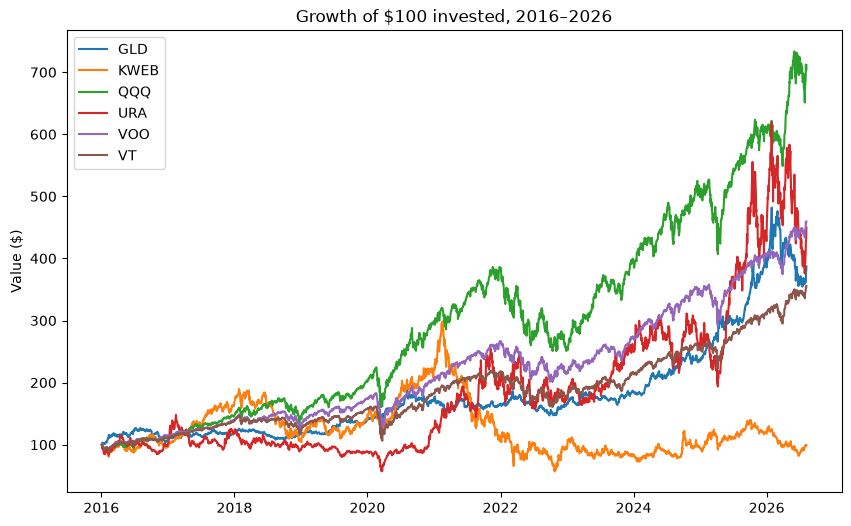

In [ ]:
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots()
for col in normalized.columns:
    ax.plot(normalized.index, normalized[col], label=col)

ax.set_title("Growth of $100 invested, 2016–2026")
ax.set_ylabel("Value ($)")
ax.legend()
plt.show()

## 2. Return distributions

Histogram of daily log returns per asset, with a normal distribution (same mean/std) overlaid in red for comparison. Where the actual histogram has a taller peak and fatter tails than the red curve, that's visual evidence against the normality assumption parametric VaR relies on.

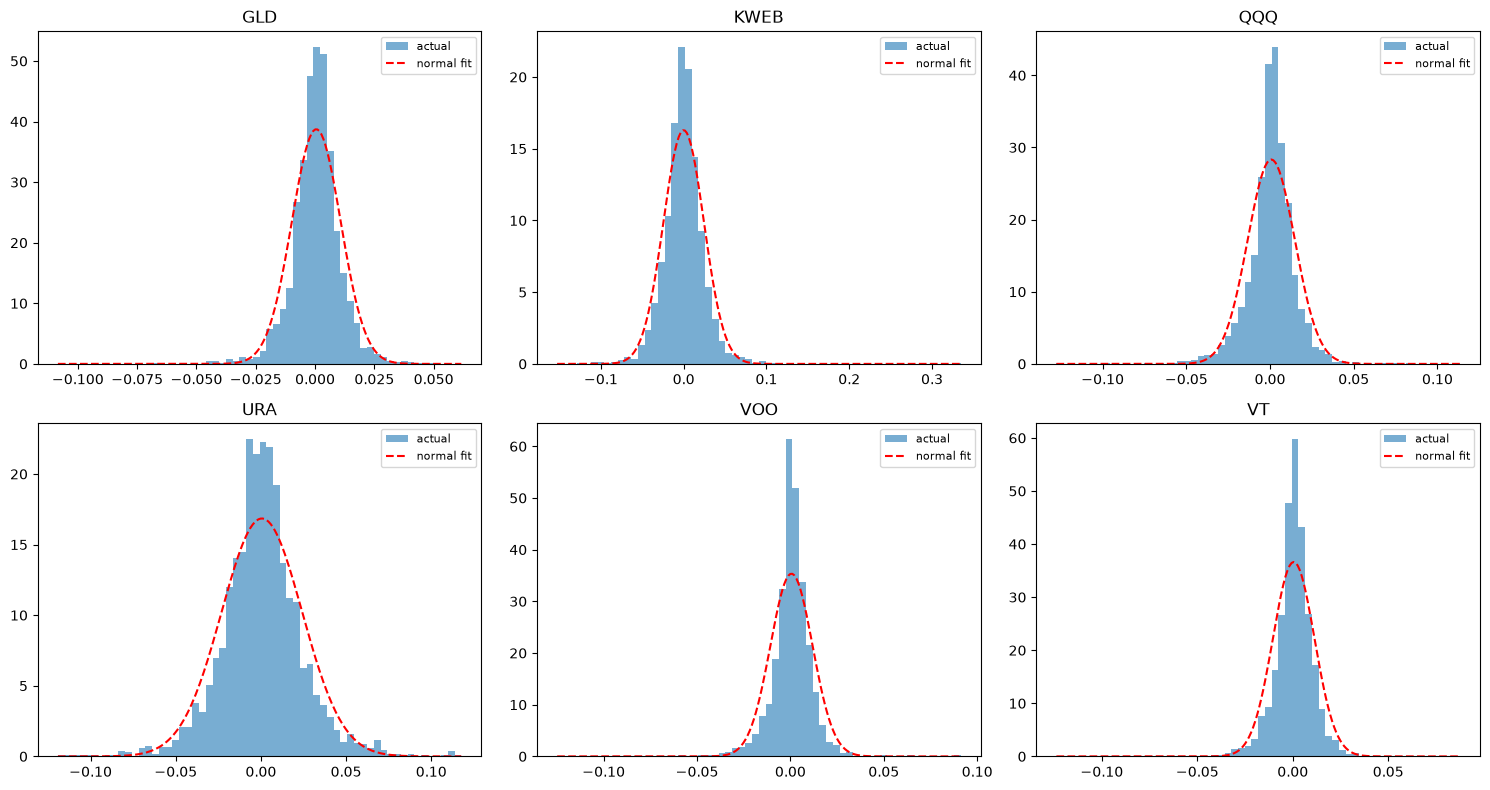

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, log_returns.columns):
    r = log_returns[col]
    ax.hist(r, bins=60, density=True, alpha=0.6, label="actual")

    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r--", label="normal fit")

    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Distribution summary — skew, kurtosis, normality test

Parametric VaR (Phase 5) assumes normal returns. This table is what confirms or challenges that assumption per asset:

- **skew** — which direction the tail leans
- **excess_kurtosis** — how much fatter the tails are than normal (0 = normal, positive = fat tails)
- **jarque_bera_pvalue** — below 0.05 rejects normality with statistical backing

In [ ]:
def distribution_summary(log_returns: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in log_returns.columns:
        r = log_returns[col]
        jb_stat, jb_pvalue = stats.jarque_bera(r)
        rows.append({
            "ticker": col,
            "ann_mean_%": r.mean() * 252 * 100,
            "ann_vol_%": r.std() * (252 ** 0.5) * 100,
            "skew": stats.skew(r),
            "excess_kurtosis": stats.kurtosis(r),  # Fisher's definition: normal = 0
            "jarque_bera_pvalue": jb_pvalue,
        })
    return pd.DataFrame(rows).set_index("ticker")

summary = distribution_summary(log_returns)
summary

,ann_mean_%,ann_vol_%,skew,excess_kurtosis,jarque_bera_pvalue
ticker,,,,,
GLD,12.812651,16.347550,-0.645186,7.875277,0.000000e+00
KWEB,-0.105182,38.858959,0.843085,15.294968,0.000000e+00
QQQ,18.569758,22.350011,-0.389725,7.512050,0.000000e+00
URA,14.227143,37.583757,0.099432,2.721312,4.129135e-180
VOO,14.433292,17.911604,-0.667770,16.301678,0.000000e+00
VT,12.011746,17.290385,-0.962606,17.257952,0.000000e+00


## 4. Correlation matrix

What the Phase 3 optimizer can exploit for diversification — the lower the correlation between two assets, the more risk reduction comes from holding both together.

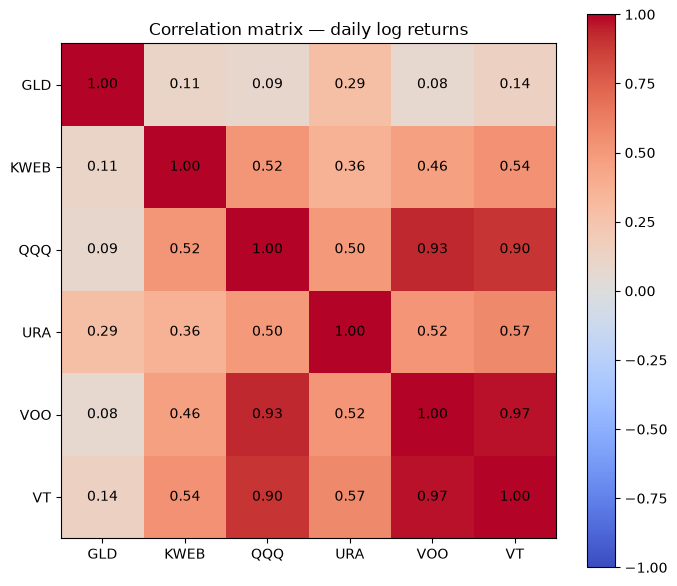

,GLD,KWEB,QQQ,URA,VOO,VT
GLD,1.000000,0.109454,0.093688,0.286177,0.076772,0.138671
KWEB,0.109454,1.000000,0.515282,0.359501,0.461120,0.538989
QQQ,0.093688,0.515282,1.000000,0.499529,0.930304,0.897543
URA,0.286177,0.359501,0.499529,1.000000,0.521600,0.573672
VOO,0.076772,0.461120,0.930304,0.521600,1.000000,0.971914
VT,0.138671,0.538989,0.897543,0.573672,0.971914,1.000000


In [ ]:
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlation matrix — daily log returns")
fig.colorbar(im)
plt.tight_layout()
plt.show()

corr

## Notes

_Fill in once run: which assets showed the fattest tails / lowest JB p-values, and which pairs came out least correlated._